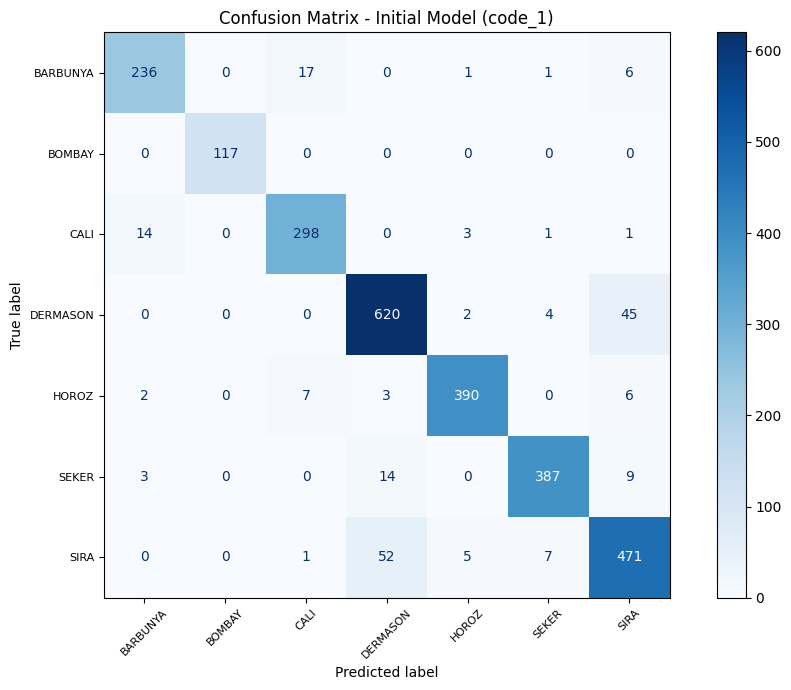

              precision    recall  f1-score   support

    BARBUNYA       0.93      0.90      0.91       261
      BOMBAY       1.00      1.00      1.00       117
        CALI       0.92      0.94      0.93       317
    DERMASON       0.90      0.92      0.91       671
       HOROZ       0.97      0.96      0.96       408
       SEKER       0.97      0.94      0.95       413
        SIRA       0.88      0.88      0.88       536

    accuracy                           0.93      2723
   macro avg       0.94      0.93      0.94      2723
weighted avg       0.93      0.93      0.93      2723



In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# 1. Load the data
# Replace 'dry_beans.csv' with your actual filename
df = pd.read_csv('dry_beans.csv')

# 2. Separate Features (X) and Target (y)
# Assuming the last column is the bean type (Class)
X = df.drop(columns=['Class'])
y = df['Class']

# 3. Split into Training (80%) and Validation (20%) sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Initialize and Train the Random Forest
# We start with basic settings (100 trees)
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 5. Make Predictions
y_pred = model.predict(X_val)

# 6. Create the Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
fig, ax = plt.subplots(figsize=(10, 7)) # Added 'ax' here to control the plot

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

# Plotting with a smaller font for the numbers inside the boxes
disp.plot(cmap='Blues', values_format='d', ax=ax, xticks_rotation=45)

# Shrink the axis labels (the bean names)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

# Optional: Shrink the "Predicted Label" and "True Label" titles
ax.xaxis.label.set_size(10)
ax.yaxis.label.set_size(10)

plt.title('Confusion Matrix - Initial Model (code_1)')
plt.tight_layout() # This helps prevent labels from getting cut off at the edges
plt.show()

# 7. Print overall accuracy
print(classification_report(y_val, y_pred))